In [1]:
# Assignment - 6
# Regression Analysis Using the California Housing Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import fetch_california_housing

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR

In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [6]:
# Load the California Housing dataset
housing = fetch_california_housing()

In [7]:
# Convert the dataset into a Pandas DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)

In [8]:
# Add the target variable
df["MedHouseVal"] = housing.target

In [9]:
# Display the first five rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [11]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [12]:
print("Number of rows:", df.shape[0])

Number of rows: 20640


In [13]:
print("Number of columns:", df.shape[1])

Number of columns: 9


In [14]:
print(df.isnull().sum())

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [15]:
# Independent variables (features)
X = df.drop("MedHouseVal", axis=1)

In [16]:
# Dependent variable (target)
y = df["MedHouseVal"]

In [17]:
print("Features:")
print(X.head())

Features:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


In [18]:
print("Target:")
print(y.head())

Target:
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [20]:
print("Training data shape:", X_train.shape)

Training data shape: (16512, 8)


In [21]:
print("Testing data shape:", X_test.shape)

Testing data shape: (4128, 8)


In [22]:
# Create the StandardScaler object
scaler = StandardScaler()

In [23]:
# Fit and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

In [24]:
# Transform the testing data
X_test_scaled = scaler.transform(X_test)

In [25]:
# Create the model
linear_model = LinearRegression()

In [26]:
# Train the model
linear_model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
# Make predictions
y_pred_linear = linear_model.predict(X_test_scaled)

In [28]:
# Create the model
dt_model = DecisionTreeRegressor(
    random_state=42
)

In [29]:
# Train the model
dt_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [30]:
# Make predictions
y_pred_dt = dt_model.predict(X_test)

In [31]:
# Create the model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [32]:
# Train the model
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
# Make predictions
y_pred_rf = rf_model.predict(X_test)

In [34]:
# Create the model
gb_model = GradientBoostingRegressor(
    random_state=42
)

In [35]:
# Train the model
gb_model.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [36]:
# Make predictions
y_pred_gb = gb_model.predict(X_test)

In [37]:
# Create the model
svr_model = SVR(
    kernel="rbf"
)

In [38]:
# Train the model
svr_model.fit(X_train_scaled, y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [39]:
# Make predictions
y_pred_svr = svr_model.predict(X_test_scaled)

In [40]:
def evaluate_model(model_name, y_actual, y_predicted):
    
    mse = mean_squared_error(y_actual, y_predicted)
    mae = mean_absolute_error(y_actual, y_predicted)
    r2 = r2_score(y_actual, y_predicted)
    
    return {
        "Model": model_name,
        "MSE": mse,
        "MAE": mae,
        "R2 Score": r2
    }

In [41]:
results = []

# Linear Regression
results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        y_pred_linear
    )
)

In [42]:
# Decision Tree
results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        y_pred_dt
    )
)

In [43]:
# Random Forest
results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        y_pred_rf
    )
)

In [44]:
# Gradient Boosting
results.append(
    evaluate_model(
        "Gradient Boosting",
        y_test,
        y_pred_gb
    )
)

In [45]:
# SVR
results.append(
    evaluate_model(
        "Support Vector Regression",
        y_test,
        y_pred_svr
    )
)

In [46]:
results_df = pd.DataFrame(results)

In [47]:
results_df

,Model,MSE,MAE,R2 Score
0,Linear Regression,0.555892,0.533200,0.575788
1,Decision Tree,0.495235,0.454679,0.622076
2,Random Forest,0.255368,0.327543,0.805123
3,Gradient Boosting,0.293997,0.371643,0.775645
4,Support Vector Regression,0.357004,0.398599,0.727563


In [48]:
results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

In [49]:
results_df

,Model,MSE,MAE,R2 Score
2,Random Forest,0.255368,0.327543,0.805123
3,Gradient Boosting,0.293997,0.371643,0.775645
4,Support Vector Regression,0.357004,0.398599,0.727563
1,Decision Tree,0.495235,0.454679,0.622076
0,Linear Regression,0.555892,0.533200,0.575788


In [50]:
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<BarContainer object of 5 artists>

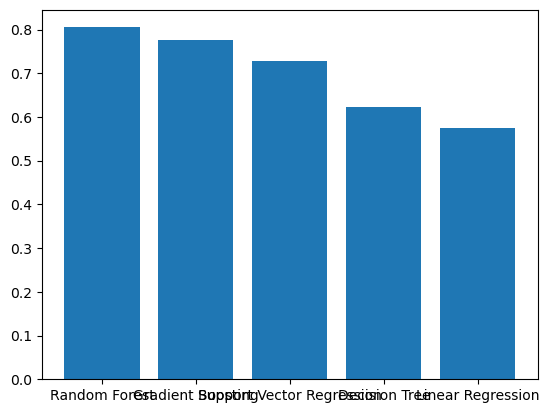

In [51]:
plt.bar(
    results_df["Model"],
    results_df["R2 Score"]
)

Text(0, 0.5, 'R² Score')

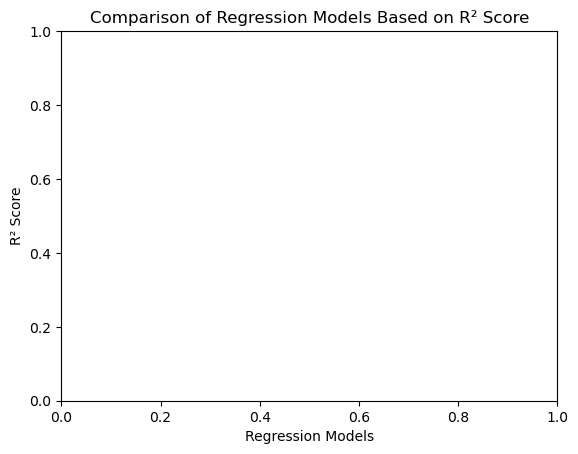

In [52]:
plt.title("Comparison of Regression Models Based on R² Score")
plt.xlabel("Regression Models")
plt.ylabel("R² Score")

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0, 0, '1.0')])

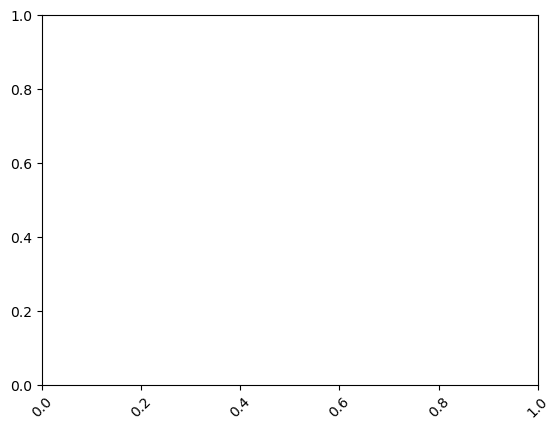

In [53]:
plt.xticks(rotation=45)

In [54]:
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

In [55]:
plt.show()

In [56]:
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<BarContainer object of 5 artists>

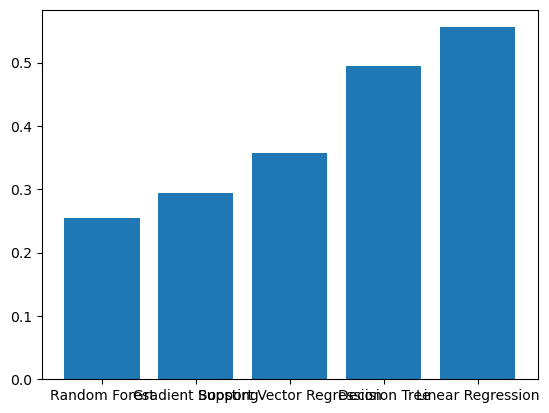

In [57]:
plt.bar(
    results_df["Model"],
    results_df["MSE"]
)

Text(0, 0.5, 'Mean Squared Error')

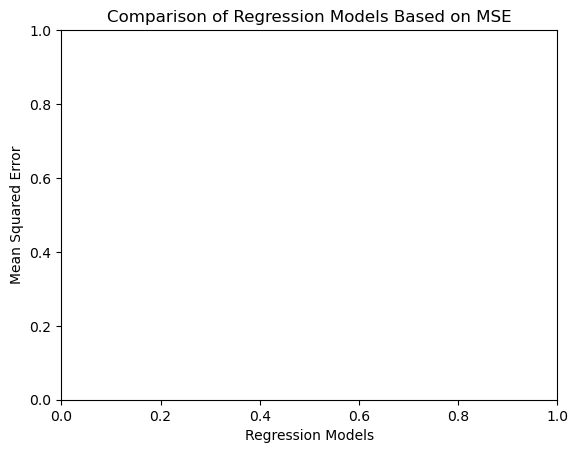

In [58]:
plt.title("Comparison of Regression Models Based on MSE")
plt.xlabel("Regression Models")
plt.ylabel("Mean Squared Error")

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0, 0, '1.0')])

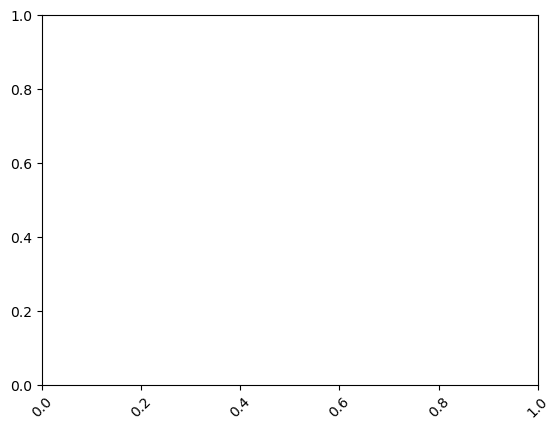

In [59]:
plt.xticks(rotation=45)

In [60]:
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

In [61]:
plt.show()

In [62]:
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<BarContainer object of 5 artists>

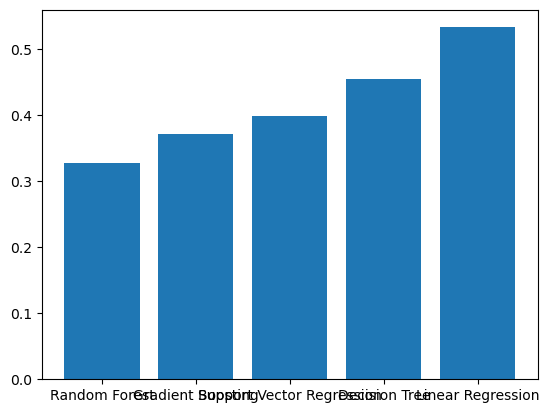

In [63]:
plt.bar(
    results_df["Model"],
    results_df["MAE"]
)

Text(0, 0.5, 'Mean Absolute Error')

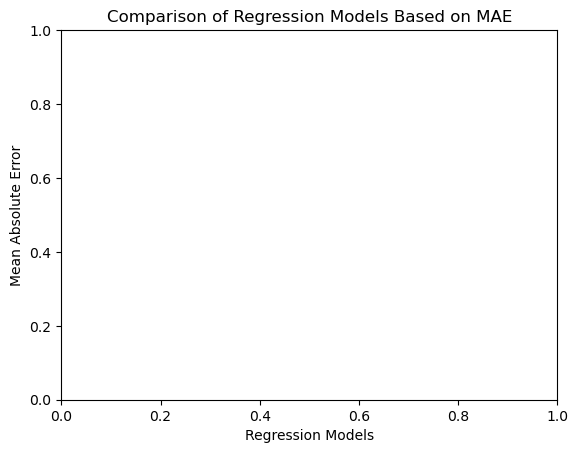

In [64]:
plt.title("Comparison of Regression Models Based on MAE")
plt.xlabel("Regression Models")
plt.ylabel("Mean Absolute Error")

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0, 0, '1.0')])

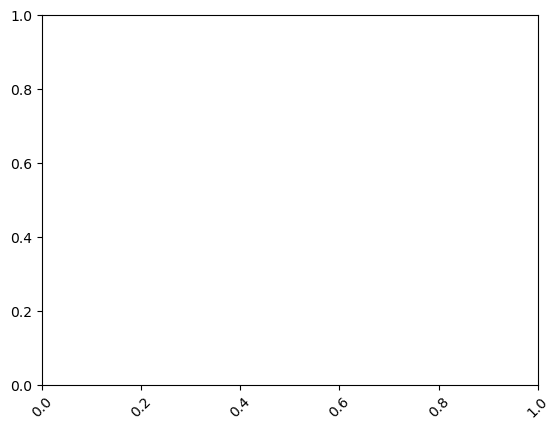

In [65]:
plt.xticks(rotation=45)

In [66]:
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

In [67]:
plt.show()

In [68]:
# Best model based on R² score
best_model = results_df.loc[
    results_df["R2 Score"].idxmax()
]

In [69]:
# Worst model based on R² score
worst_model = results_df.loc[
    results_df["R2 Score"].idxmin()
]

In [70]:
print("Best Performing Model:")

Best Performing Model:


In [71]:
print(best_model)

Model       Random Forest
MSE              0.255368
MAE              0.327543
R2 Score         0.805123
Name: 2, dtype: object


In [72]:
print("Worst Performing Model:")

Worst Performing Model:


In [73]:
print(worst_model)

Model       Linear Regression
MSE                  0.555892
MAE                    0.5332
R2 Score             0.575788
Name: 0, dtype: object


In [74]:
# Identify the best model name

best_model_name = best_model["Model"]

In [75]:
# Store predictions corresponding to each model
predictions = {
    "Linear Regression": y_pred_linear,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb,
    "Support Vector Regression": y_pred_svr
}

In [76]:
# Get predictions of the best model

best_predictions = predictions[best_model_name]

In [77]:
plt.figure(figsize=(8, 6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

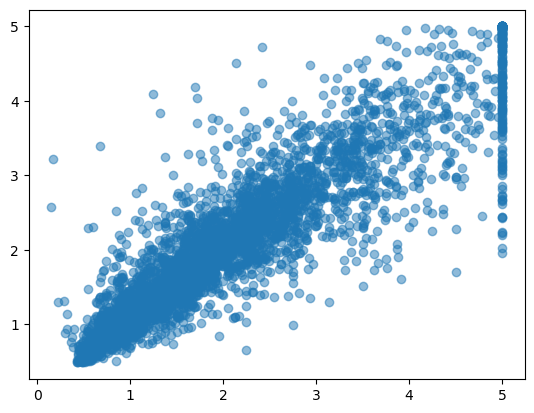

In [78]:
plt.scatter(
    y_test,
    best_predictions,
    alpha=0.5
)

Text(0.5, 0, 'Actual House Prices')

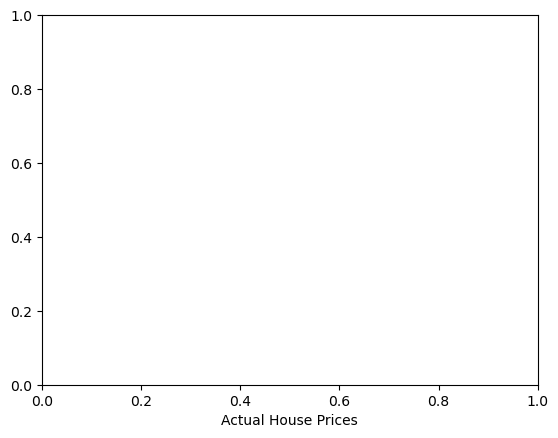

In [79]:
plt.xlabel("Actual House Prices")

Text(0, 0.5, 'Predicted House Prices')

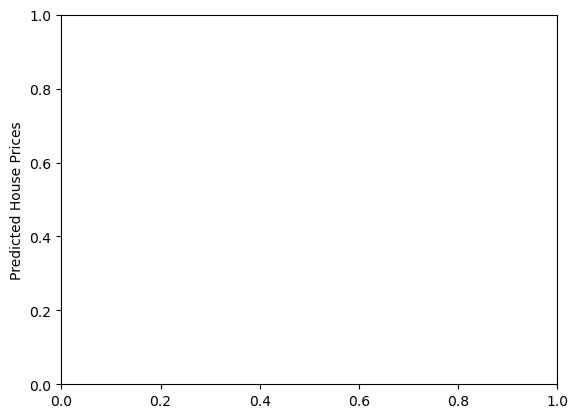

In [80]:
plt.ylabel("Predicted House Prices")

Text(0.5, 1.0, 'Actual vs Predicted Values - Random Forest')

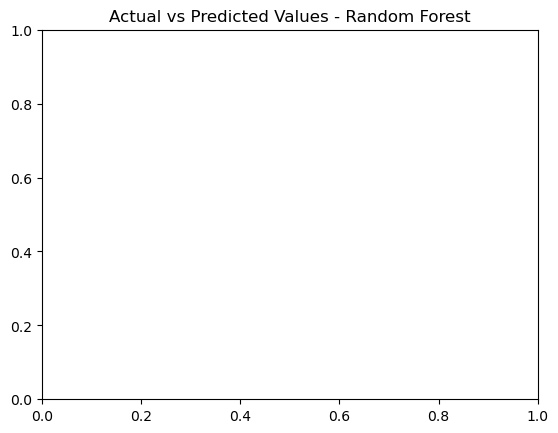

In [81]:
plt.title(
    f"Actual vs Predicted Values - {best_model_name}"
)

In [82]:
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

In [83]:
plt.show()

In [84]:
print("Target:")
print(y_test.head())
print("Best Predictions:")

Target:
20046    0.47700
3024     0.45800
15663    5.00001
20484    2.18600
9814     2.78000
Name: MedHouseVal, dtype: float64
Best Predictions:
